<a href="https://colab.research.google.com/github/devanshRaana/housing_price_predict/blob/main/PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR, SVC, LinearSVR
from sklearn.linear_model import SGDRegressor, SGDClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix,
    r2_score,
    ConfusionMatrixDisplay,
    log_loss
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

In [ ]:
file_path = "/content/kc_house_data.csv"
housing_data = pd.read_csv(file_path)

cols_to_drop = ["id", "date"]
housing_data.drop(columns=[col for col in cols_to_drop if col in housing_data.columns], inplace=True)
housing_data.fillna(housing_data.median(numeric_only=True), inplace=True)

target_col = "price"
feature_cols = [c for c in housing_data.columns if c != target_col]

In [ ]:
X_features = housing_data[feature_cols].copy()
y_continuous = housing_data[target_col].copy()

# Filter X_features to include only numeric columns for scaling
numeric_cols = X_features.select_dtypes(include=['number']).columns
X_features = X_features[numeric_cols]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_features, y_continuous, test_size=0.2, random_state=42
)

reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = reg_scaler.transform(X_test_reg)

In [ ]:
p33 = y_continuous.quantile(0.33)
p66 = y_continuous.quantile(0.66)

y_categories = pd.cut(
    y_continuous,
    bins=[-np.inf, p33, p66, np.inf],
    labels=["low", "mid", "high"]
)

high_mask = y_categories == 'high'
drop_indices = y_categories[high_mask].sample(frac=0.55, random_state=42).index
balanced_df = housing_data.drop(index=drop_indices).reset_index(drop=True)

X_cls_features = balanced_df[feature_cols].copy()
# Filter X_cls_features to include only numeric columns for scaling
numeric_cls_cols = X_cls_features.select_dtypes(include=['number']).columns
X_cls_features = X_cls_features[numeric_cls_cols]

y_cls_target = pd.cut(
    balanced_df[target_col],
    bins=[-np.inf, p33, p66, np.inf],
    labels=["low", "mid", "high"]
)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_cls_target)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_features, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

cls_scaler = StandardScaler()
X_train_cls_scaled = cls_scaler.fit_transform(X_train_cls)
X_test_cls_scaled = cls_scaler.transform(X_test_cls)

smote_sampler = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train_cls_scaled, y_train_cls)

Classification Report:
              precision    recall  f1-score   support

        high       0.52      0.66      0.58       140
         low       0.70      0.70      0.70       304
         mid       0.60      0.53      0.56       305

    accuracy                           0.62       749
   macro avg       0.61      0.63      0.61       749
weighted avg       0.63      0.62      0.62       749

Accuracy: 62.21628838451269%


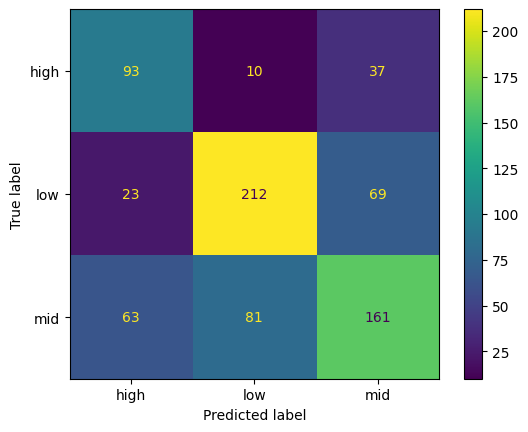

In [ ]:
svc_classifier = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42)
svc_classifier.fit(X_train_smote, y_train_smote)
svc_predictions = svc_classifier.predict(X_test_cls_scaled)

print("Classification Report:")
print(classification_report(y_test_cls, svc_predictions, target_names=label_encoder.classes_))
svc_accuracy = np.mean(svc_predictions == y_test_cls)
print(f"Accuracy: {svc_accuracy * 100}%")

conf_matrix = confusion_matrix(y_test_cls, svc_predictions)
matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=label_encoder.classes_)
matrix_display.plot()
plt.show()

Regression Metrics:
MAE: 201143.02024786486
RMSE: 989501.5987762958
R^2: 0.03994025815951474


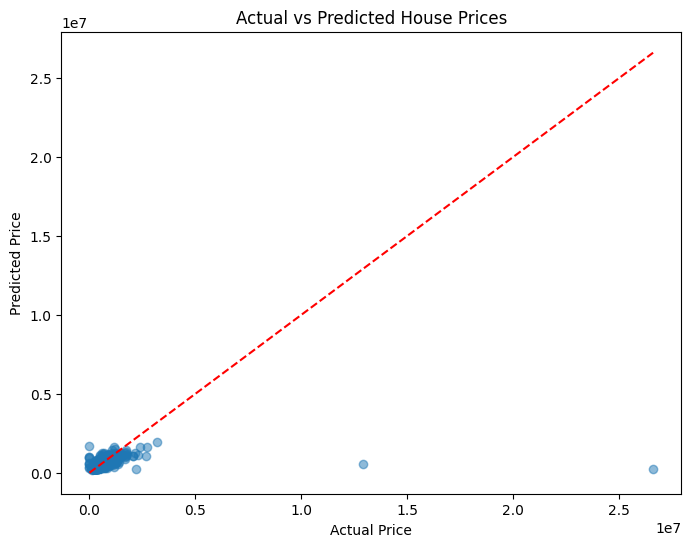

In [ ]:
svr_regressor = SVR(kernel="rbf", C=600000, epsilon=0.01, gamma=0.02)
svr_regressor.fit(X_train_reg_scaled, y_train_reg)
svr_predictions = svr_regressor.predict(X_test_reg_scaled)

def compute_regression_metrics():
    mae = mean_absolute_error(y_test_reg, svr_predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, svr_predictions))
    r2 = r2_score(y_test_reg, svr_predictions)
    print("Regression Metrics:")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R^2: {r2}")

compute_regression_metrics()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, svr_predictions, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

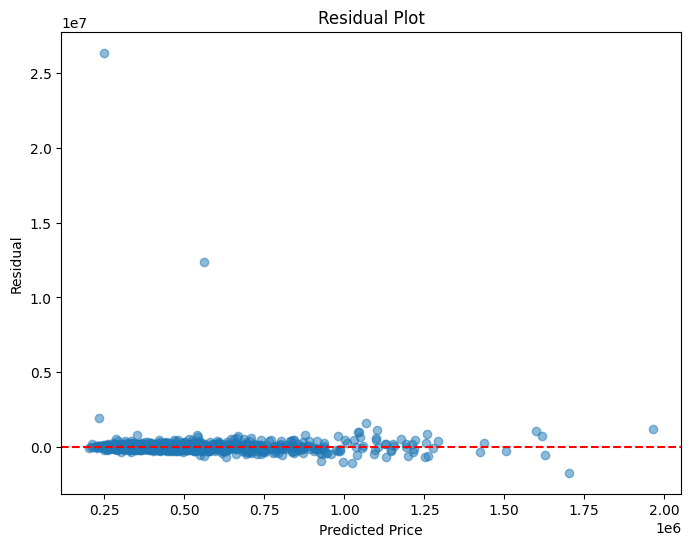

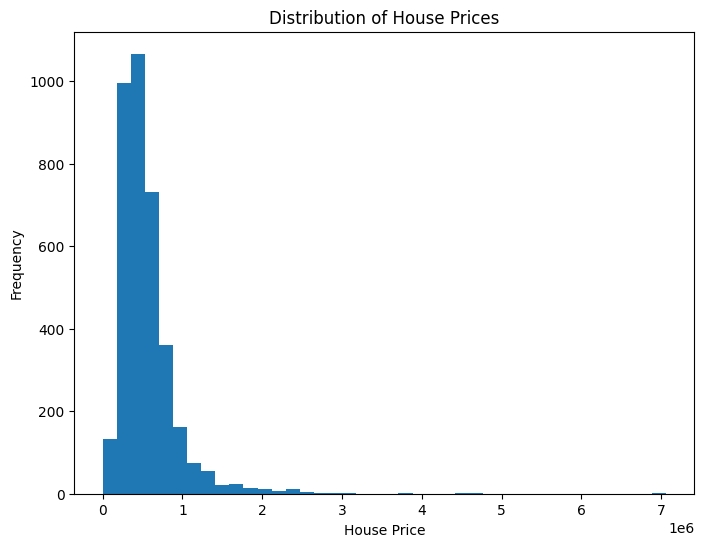

In [ ]:
residuals = y_test_reg - svr_predictions
plt.figure(figsize=(8, 6))
plt.scatter(svr_predictions, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--", color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(y_train_reg, bins=40)
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

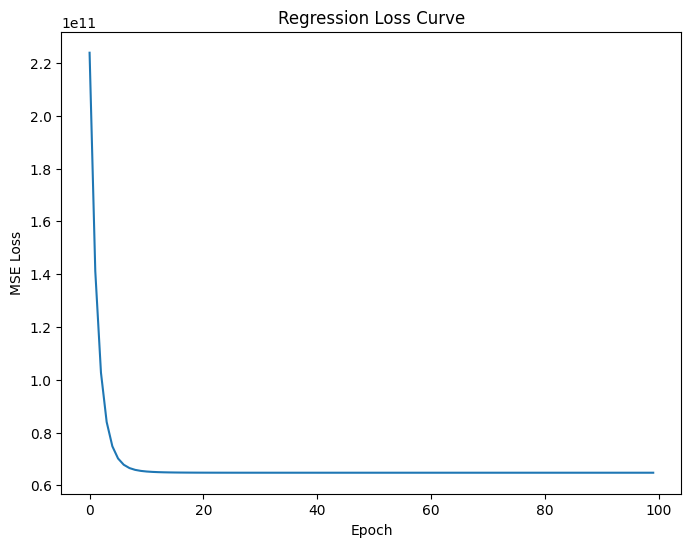

In [ ]:
sgd_regressor = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.0001, warm_start=True, random_state=42)
regression_losses = []

for _ in range(100):
    sgd_regressor.fit(X_train_reg_scaled, y_train_reg)
    iter_preds = sgd_regressor.predict(X_train_reg_scaled)
    regression_losses.append(mean_squared_error(y_train_reg, iter_preds))

plt.figure(figsize=(8, 6))
plt.plot(regression_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression Loss Curve")
plt.show()

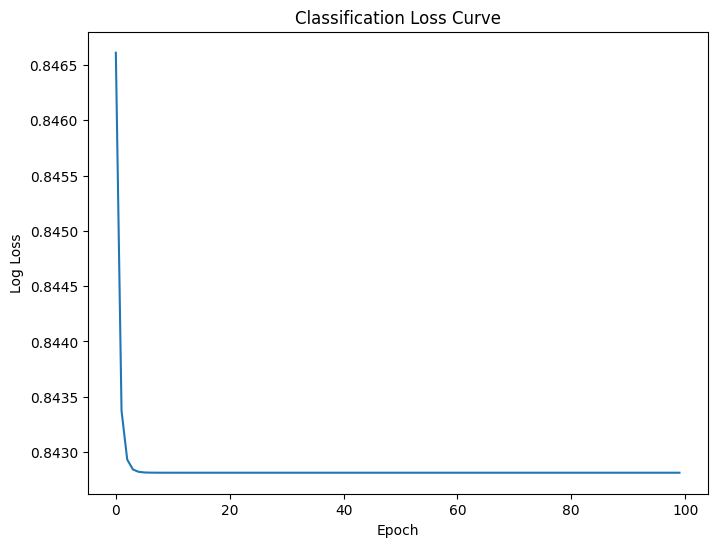

In [ ]:
sgd_classifier = SGDClassifier(loss='log_loss', max_iter=1, learning_rate='constant', eta0=0.01, warm_start=True, random_state=42)
unique_labels = np.unique(y_train_smote)
classification_losses = []

for _ in range(100):
    sgd_classifier.partial_fit(X_train_smote, y_train_smote, classes=unique_labels)
    iter_probs = sgd_classifier.predict_proba(X_train_smote)
    classification_losses.append(log_loss(y_train_smote, iter_probs))

plt.figure(figsize=(8, 6))
plt.plot(classification_losses)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Classification Loss Curve")
plt.show()

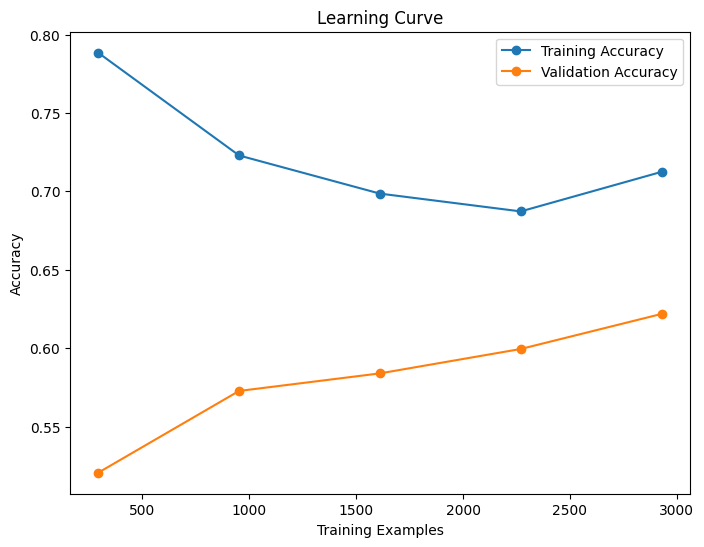

In [ ]:
train_sizes_arr, train_scores_arr, val_scores_arr = learning_curve(
    SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced", random_state=42),
    X_train_smote, y_train_smote, cv=5, scoring='accuracy', n_jobs=-1
)
mean_train_acc = train_scores_arr.mean(axis=1)
mean_val_acc = val_scores_arr.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_arr, mean_train_acc, marker='o', label='Training Accuracy')
plt.plot(train_sizes_arr, mean_val_acc, marker='o', label='Validation Accuracy')
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

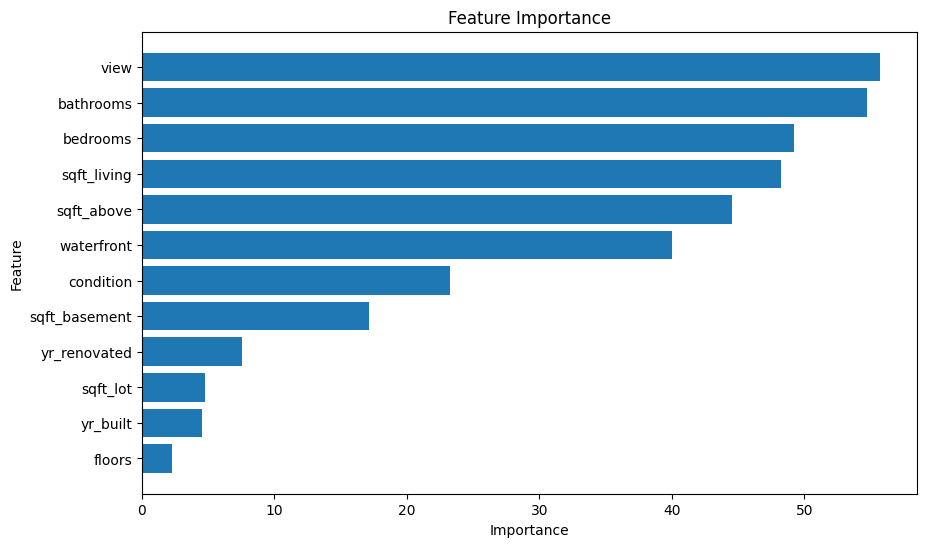

FINAL MODEL PERFORMANCE
Best SVR Parameters:
C=600000
gamma=0.02
epsilon=0.01

Regression Metrics:
MAE: 201143.02024786486
RMSE: 989501.5987762958
R^2: 0.03994025815951474


In [ ]:
linear_model = LinearSVR(random_state=42, max_iter=10000)
linear_model.fit(X_train_reg_scaled, y_train_reg)
calculated_importances = np.abs(linear_model.coef_)

importance_df = pd.DataFrame({
    'Feature': X_features.columns,
    'Importance': calculated_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print("Best SVR Parameters:")
print("C=600000\ngamma=0.02\nepsilon=0.01\n")
compute_regression_metrics()